<a href="https://colab.research.google.com/github/nknak-crypto/Machine-Learning-Supervisado/blob/main/Grupo_TP3_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Churn

## **Trabajo** **Práctico** **N°3** — Machine Learning Supervisado 2026

GRUPO 9: Knak, Guasti, Steurs & Vicente

Una empresa de telecomunicaciones desea anticipar qué clientes están en riesgo de abandonar sus servicios. Se entrena un modelo de regresión logística que predice la probabilidad de cancelación en el siguiente mes, usando variables como uso mensual, tipo de contrato, servicios adicionales y comportamiento de pago.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_curve, roc_auc_score)
from IPython.display import HTML # Import HTML

display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>✅ Librerías importadas correctamente</h3>"))

Se carga el archivo CSV con los datos de clientes de la empresa de telecomunicaciones.
Se imprime el tamaño del dataset (filas y columnas) y se muestran las primeras filas
para tener una primera vista de la información disponible.

In [9]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>1. Carga de datos</h3>"))

df = pd.read_csv("/content/TP customer_churn_prediction_dataset.csv")

print("Tamaño del dataset:", df.shape)
display(df.head(10))

Tamaño del dataset: (300, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes
5,0006-XXXX,Female,0,Yes,No,70,Yes,No phone service,No,No internet service,...,Yes,No internet service,No internet service,Yes,Month-to-month,Yes,Electronic check,43.21,3024.70,No
6,0007-XXXX,Male,1,Yes,No,1,No,No,DSL,No,...,No internet service,Yes,No internet service,Yes,Month-to-month,No,Credit card,39.80,39.80,Yes
7,0008-XXXX,Male,1,No,Yes,5,No,Yes,No,No,...,No internet service,Yes,No,No internet service,Month-to-month,No,Credit card,45.47,227.35,No
8,0009-XXXX,Male,1,No,Yes,12,No,Yes,DSL,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer,43.13,517.56,No
9,0010-XXXX,Female,1,No,No,46,Yes,No,Fiber optic,No,...,No internet service,No,No internet service,Yes,Month-to-month,Yes,Electronic check,24.53,1128.38,Yes


Se revisan los tipos de datos de cada columna, los valores nulos y la distribución
de la variable objetivo Churn. Esto permite entender con qué tipo de información
trabajamos antes de preprocesar.

In [10]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>2. Exploración inicial</h3>"))

print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Distribución de la variable objetivo (Churn):")
print(df["Churn"].value_counts())

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pa

Se genera un reporte estructural del dataset con tres secciones:

Tamaño del dataset: muestra la cantidad total de filas (clientes) y columnas
(variables) disponibles para el análisis.

Tipos de datos por columna: indica si cada variable es categórica (object)
o numérica (int64 / float64). Esto es importante porque las variables
categóricas necesitan ser convertidas a variables dummy antes de entrenar
el modelo, mientras que las numéricas pueden usarse directamente.

Valores nulos: verifica si hay datos faltantes en alguna columna. Los valores
nulos deben tratarse antes de modelar porque la regresión logística no puede
trabajar con datos incompletos.

Estadísticas descriptivas: muestra métricas como el promedio, desvío estándar,
mínimo y máximo de las variables numéricas. Permite detectar variables con
rangos muy diferentes (por ejemplo, tenure va de 1 a 72 meses mientras que
TotalCharges llega a valores de miles), lo que justifica aplicar escalado
en pasos posteriores.

In [11]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>3. Reporte EDA</h3>"))

# --- Tamaño ---
filas, columnas = df.shape
display(HTML(f"""
<div style='font-family:Arial; background:#1e2a3a; border-left:5px solid #1A56DB;
            padding:12px 20px; border-radius:8px; margin-bottom:20px; color:white'>
  <b>Tamaño del dataset:</b> {filas} filas × {columnas} columnas
</div>
"""))

# --- Tipos de datos ---
display(HTML("<b style='font-family:Arial; font-size:14px; color:white'>Tipos de datos por columna:</b>"))

tipos = df.dtypes.reset_index()
tipos.columns = ["Columna", "Tipo"]

filas_html = ""
for i, row in tipos.iterrows():
    badge_color = "#1A56DB" if str(row["Tipo"]) == "object" else "#1E7E34"
    bg = "#1e2a3a" if i % 2 == 0 else "#253347"
    filas_html += f"""
    <tr style='background:{bg}'>
      <td style='padding:8px 15px; font-family:Arial; font-size:13px; color:white'>{row['Columna']}</td>
      <td style='padding:8px 15px; text-align:center'>
        <span style='background:{badge_color}; color:white; padding:3px 10px;
                     border-radius:12px; font-size:12px; font-family:Arial'>
          {row['Tipo']}
        </span>
      </td>
    </tr>"""

display(HTML(f"""
<table style='border-collapse:collapse; width:40%; margin:10px 0 20px 0;
              border-radius:8px; overflow:hidden; box-shadow:0 1px 4px #000'>
  <thead>
    <tr style='background:#1A56DB'>
      <th style='padding:10px 15px; color:white; font-family:Arial; text-align:left'>Columna</th>
      <th style='padding:10px 15px; color:white; font-family:Arial; text-align:center'>Tipo</th>
    </tr>
  </thead>
  <tbody>{filas_html}</tbody>
</table>
"""))

# --- Valores nulos ---
display(HTML("<b style='font-family:Arial; font-size:14px; color:white'>Valores nulos por columna:</b>"))
nulos = df.isnull().sum()
if nulos.sum() == 0:
    display(HTML("""
    <div style='font-family:Arial; background:#1a3a2a; border-left:5px solid #1E7E34;
                padding:12px 20px; border-radius:8px; margin:10px 0 20px 0; color:white'>
      ✅ No se encontraron valores nulos en el dataset.
    </div>
    """))
else:
    nulos_html = ""
    for i, (col, val) in enumerate(nulos[nulos > 0].items()):
        bg = "#1e2a3a" if i % 2 == 0 else "#253347"
        nulos_html += f"""
        <tr style='background:{bg}'>
          <td style='padding:8px 15px; font-family:Arial; color:white'>{col}</td>
          <td style='padding:8px 15px; text-align:center; color:#e74c3c;
                     font-weight:bold; font-size:14px'>{val}</td>
        </tr>"""
    display(HTML(f"""
    <table style='border-collapse:collapse; width:40%; margin:10px 0 20px 0;
                  border-radius:8px; overflow:hidden; box-shadow:0 1px 4px #000'>
      <thead>
        <tr style='background:#1A56DB'>
          <th style='padding:10px 15px; color:white; font-family:Arial; text-align:left'>Columna</th>
          <th style='padding:10px 15px; color:white; font-family:Arial; text-align:center'>Nulos</th>
        </tr>
      </thead>
      <tbody>{nulos_html}</tbody>
    </table>
    """))

# --- Estadísticas descriptivas ---
display(HTML("<b style='font-family:Arial; font-size:14px; color:white'>Estadísticas descriptivas (variables numéricas):</b>"))

desc = df.describe().round(2).reset_index()
desc.rename(columns={"index": "Métrica"}, inplace=True)

header_html = "".join([
    f"<th style='padding:10px 15px; color:white; font-family:Arial; text-align:center'>{col}</th>"
    for col in desc.columns
])

filas_desc = ""
for i, row in desc.iterrows():
    bg = "#1e2a3a" if i % 2 == 0 else "#253347"
    celdas = f"<td style='padding:8px 15px; font-family:Arial; font-weight:bold; font-size:13px; color:#7eb8f7'>{row['Métrica']}</td>"
    for col in desc.columns[1:]:
        celdas += f"<td style='padding:8px 15px; text-align:center; font-family:Arial; font-size:13px; color:white'>{row[col]}</td>"
    filas_desc += f"<tr style='background:{bg}'>{celdas}</tr>"

display(HTML(f"""
<table style='border-collapse:collapse; width:70%; margin:10px 0;
              border-radius:8px; overflow:hidden; box-shadow:0 1px 4px #000'>
  <thead>
    <tr style='background:#1A56DB'>{header_html}</tr>
  </thead>
  <tbody>{filas_desc}</tbody>
</table>
"""))

Columna,Tipo
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Métrica,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,300.0,300.0,300.0,300.0
mean,0.54,35.78,67.23,2477.98
std,0.5,21.11,28.64,1918.54
min,0.0,1.0,18.45,30.03
25%,0.0,17.0,42.34,910.3
50%,1.0,36.0,68.64,2072.4
75%,1.0,53.25,92.43,3618.4
max,1.0,72.0,118.64,8318.88


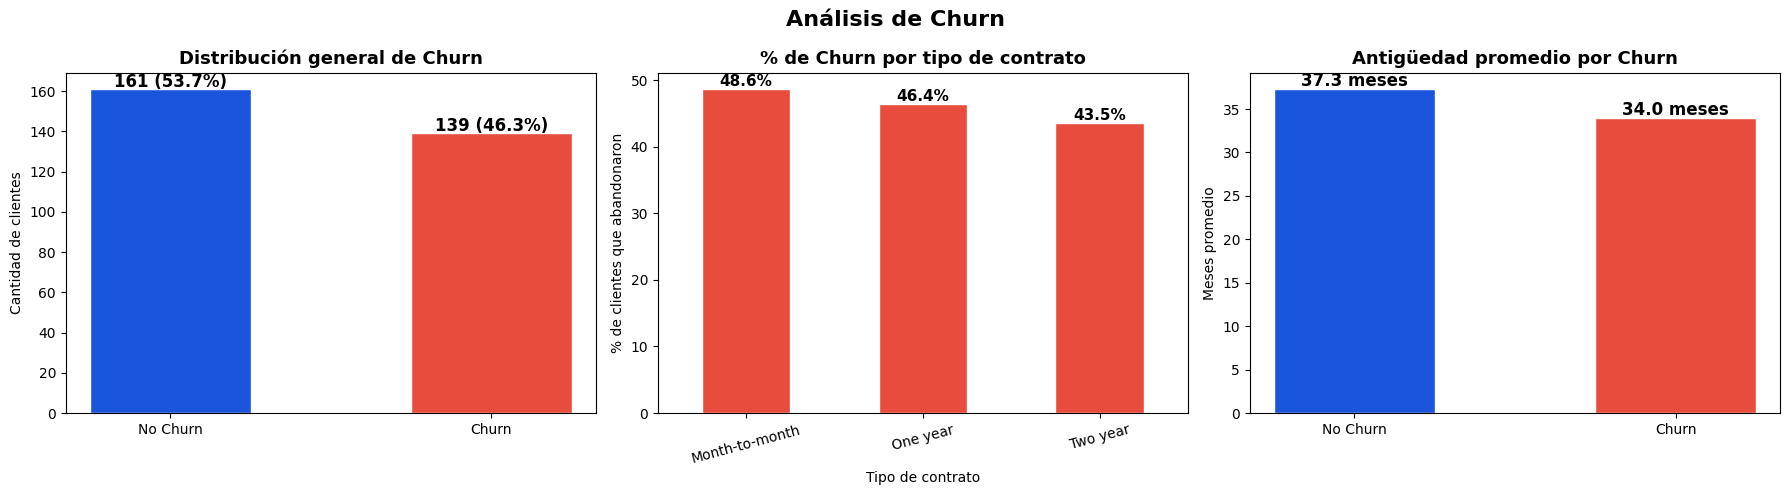

In [12]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>Análisis de la variable objetivo — Churn</h3>"))

# --- Cálculos ---
churn_counts = df["Churn"].value_counts()
porc_si = round(churn_counts["Yes"] / len(df) * 100, 1)
porc_no = round(churn_counts["No"] / len(df) * 100, 1)

contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100
tenure_churn_si = df[df["Churn"] == "Yes"]["tenure"].mean().round(1)
tenure_churn_no = df[df["Churn"] == "No"]["tenure"].mean().round(1)

# --- Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Churn", fontsize=16, fontweight="bold")

# Gráfico 1: Distribución general
axes[0].bar(["No Churn", "Churn"], churn_counts.values,
            color=["#1A56DB", "#e74c3c"], edgecolor="white", width=0.5)
axes[0].set_title("Distribución general de Churn", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Cantidad de clientes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1, f"{v} ({[porc_no, porc_si][i]}%)",
                 ha="center", fontsize=12, fontweight="bold")

# Gráfico 2: Churn por tipo de contrato
contract_churn["Yes"].plot(kind="bar", ax=axes[1], color="#e74c3c", edgecolor="white", width=0.5)
axes[1].set_title("% de Churn por tipo de contrato", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tipo de contrato")
axes[1].set_ylabel("% de clientes que abandonaron")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(contract_churn["Yes"]):
    axes[1].text(i, v + 0.5, f"{round(v, 1)}%", ha="center", fontsize=11, fontweight="bold")

# Gráfico 3: Antigüedad promedio por Churn
tenure_vals = [tenure_churn_no, tenure_churn_si]
axes[2].bar(["No Churn", "Churn"], tenure_vals,
            color=["#1A56DB", "#e74c3c"], edgecolor="white", width=0.5)
axes[2].set_title("Antigüedad promedio por Churn", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Meses promedio")
for i, v in enumerate(tenure_vals):
    axes[2].text(i, v + 0.3, f"{v} meses", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# --- Análisis escrito ---
display(HTML(f"""
<div style='font-family:Arial; font-size:14px; line-height:1.8; margin-top:15px'>

  <div style='background:#1e2a3a; border-left:5px solid #1A56DB;
              padding:15px 20px; border-radius:8px; margin-bottom:12px; color:white'>
    <b style='color:#7eb8f7'>📊 Distribución general</b><br><br>
    El dataset cuenta con <b>{churn_counts["No"]} clientes que no abandonaron ({porc_no}%)</b>
    y <b>{churn_counts["Yes"]} que sí lo hicieron ({porc_si}%)</b>. La distribución es
    balanceada, lo que es favorable para el modelo ya que no hay una clase
    dominante que pueda sesgar las predicciones.
  </div>

  <div style='background:#1e2a3a; border-left:5px solid #e74c3c;
              padding:15px 20px; border-radius:8px; margin-bottom:12px; color:white'>
    <b style='color:#e74c3c'>📋 Tipo de contrato</b><br><br>
    Los clientes con contrato <b>mensual (Month-to-month)</b> presentan la mayor
    tasa de abandono ({round(contract_churn["Yes"]["Month-to-month"], 1)}%).
    En cambio, los clientes con contratos anuales o bianuales muestran tasas
    significativamente menores. Esto indica que el tipo de contrato es una
    de las variables más relevantes para predecir el churn: a menor compromiso
    contractual, mayor riesgo de abandono.
  </div>

  <div style='background:#1e2a3a; border-left:5px solid #1E7E34;
              padding:15px 20px; border-radius:8px; margin-bottom:12px; color:white'>
    <b style='color:#5cb85c'>📅 Antigüedad del cliente (Tenure)</b><br><br>
    Los clientes que abandonaron llevan en promedio <b>{tenure_churn_si} meses</b>
    en la empresa, mientras que los que no abandonaron llevan <b>{tenure_churn_no} meses</b>.
    Esto confirma que los clientes más nuevos son los más propensos a irse.
    Los primeros meses son el período más crítico para retener al cliente.
  </div>

  <div style='background:#0e3a8a; border-radius:8px; padding:15px 20px;
              color:white'>
    <b>💡 Variables clave identificadas</b><br><br>
    El análisis exploratorio sugiere que <b>Contract</b> y <b>tenure</b> son
    las variables con mayor relación con el churn. Estas serán probablemente
    las más influyentes en el modelo de regresión logística y justifican
    priorizar la retención de clientes con contrato mensual y baja antigüedad.
  </div>

</div>
"""))


Se define Churn como la variable objetivo (lo que queremos predecir).
Se elimina la columna customerID porque es un identificador que no aporta
información al modelo. Luego se convierte Churn a valores numéricos:
No = 0 y Yes = 1, ya que el modelo solo trabaja con números.

In [13]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>4. Definición de variables</h3>"))

# Variable objetivo
target = "Churn"

# Eliminamos el ID que no aporta información al modelo
X = df.drop(columns=[target, "customerID"])
y = df[target]

# Convertimos Churn a numérico: No=0, Yes=1
y = y.map({"No": 0, "Yes": 1})

print("Variable objetivo (Churn):")
print(y.value_counts())
print()
print("Variables predictoras:", list(X.columns))

Variable objetivo (Churn):
Churn
0    161
1    139
Name: count, dtype: int64

Variables predictoras: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


Se identifican las columnas numéricas y categóricas por separado.
Los valores nulos numéricos se rellenan con la mediana de cada columna,
y los categóricos con la moda. Luego se aplica get_dummies() para convertir
las variables categóricas en variables dummy (columnas de 0 y 1),
usando drop_first=True para evitar la trampa de multicolinealidad,
dejando una categoría de referencia por fuera.

In [14]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>5. Preprocesamiento — Nulos y Variables Dummy</h3>"))

# Identificar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Columnas numéricas:", list(numeric_cols))
print("Columnas categóricas:", list(categorical_cols))

# Rellenar nulos numéricos con la mediana
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Rellenar nulos categóricos con la moda
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Convertir categóricas en variables dummy (n-1 columnas por variable)
X_encoded = pd.get_dummies(X, drop_first=True)

print("\nDataset después del encoding:")
print("Shape:", X_encoded.shape)
display(X_encoded.head(5))

Columnas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Columnas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dataset después del encoding:
Shape: (300, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,5,27.43,137.15,True,True,True,False,False,True,...,False,False,True,False,False,False,True,True,False,False
1,0,42,38.28,1607.76,False,False,False,True,True,False,...,True,False,True,False,False,True,False,False,True,False
2,0,61,106.44,6492.84,True,False,False,True,True,False,...,False,True,False,False,True,False,False,False,False,False
3,1,22,92.49,2034.78,True,False,True,True,False,False,...,True,False,False,True,False,False,False,False,True,False
4,1,21,19.63,412.23,True,True,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False


Se muestra una tabla comparativa con la columna Churn original (Yes/No)
y su versión convertida a valores numéricos (1/0), para confirmar que
la transformación se realizó correctamente antes de continuar.

In [16]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>Verificación: Churn convertido a 0 y 1</h3>"))

verificacion = pd.DataFrame({
    "Churn original": df["Churn"],
    "Churn numérico": df["Churn"].map({"No": 0, "Yes": 1})
})

print("Primeras 10 filas:")
display(verificacion.head(10))

print("\nConteo de valores:")
display(verificacion["Churn numérico"].value_counts().rename({0: "No (0)", 1: "Sí (1)"}).to_frame("Cantidad"))

Primeras 10 filas:


,Churn original,Churn numérico
0,Yes,1
1,Yes,1
2,Yes,1
3,No,0
4,Yes,1
5,No,0
6,Yes,1
7,No,0
8,No,0
9,Yes,1



Conteo de valores:


,Cantidad
Churn numérico,
No (0),161
Sí (1),139


In [17]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>Verificación: Variables Dummy</h3>"))

# Mostramos cuántas columnas había antes y después del encoding
print(f"Columnas ANTES del encoding: {X.shape[1]}")
print(f"Columnas DESPUÉS del encoding: {X_encoded.shape[1]}")
print()

# Mostramos las columnas nuevas que se crearon
print("Columnas generadas por get_dummies:")
for col in X_encoded.columns:
    print(" •", col)

Columnas ANTES del encoding: 19
Columnas DESPUÉS del encoding: 30

Columnas generadas por get_dummies:
 • SeniorCitizen
 • tenure
 • MonthlyCharges
 • TotalCharges
 • gender_Male
 • Partner_Yes
 • Dependents_Yes
 • PhoneService_Yes
 • MultipleLines_No phone service
 • MultipleLines_Yes
 • InternetService_Fiber optic
 • InternetService_No
 • OnlineSecurity_No internet service
 • OnlineSecurity_Yes
 • OnlineBackup_No internet service
 • OnlineBackup_Yes
 • DeviceProtection_No internet service
 • DeviceProtection_Yes
 • TechSupport_No internet service
 • TechSupport_Yes
 • StreamingTV_No internet service
 • StreamingTV_Yes
 • StreamingMovies_No internet service
 • StreamingMovies_Yes
 • Contract_One year
 • Contract_Two year
 • PaperlessBilling_Yes
 • PaymentMethod_Credit card
 • PaymentMethod_Electronic check
 • PaymentMethod_Mailed check


Se divide el dataset en dos partes: 80% para entrenar el modelo y 20% para
evaluarlo con datos que nunca vio. Se usa stratify=y para asegurarse de que
la proporción de clientes que abandonan (Churn=1) sea similar en ambos conjuntos.

In [18]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>6. División en entrenamiento y prueba</h3>"))

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")

Entrenamiento: 240 registros
Prueba:        60 registros


Se aplica StandardScaler para normalizar las variables numéricas, llevándolas
a una escala común. Esto es importante porque la regresión logística es sensible
a variables con rangos muy diferentes (por ejemplo, tenure va de 0 a 72
mientras que MonthlyCharges va de 18 a 118). El scaler se entrena solo con
los datos de entrenamiento y luego se aplica igual al conjunto de prueba.

In [19]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>7. Escalado de variables</h3>"))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

display(HTML("<p style='font-family:Arial'>✅ Variables escaladas con StandardScaler</p>"))

Se crea el modelo de regresión logística y se entrena con los datos de
entrenamiento escalados. El parámetro max_iter=1000 asegura que el algoritmo
tenga suficientes iteraciones para converger y encontrar los coeficientes óptimos.

In [20]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>8. Entrenamiento del modelo</h3>"))

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

display(HTML("<p style='font-family:Arial'>✅ Modelo entrenado correctamente</p>"))

Se generan las predicciones sobre el conjunto de prueba y se calculan
las principales métricas de evaluación: Accuracy (porcentaje de predicciones
correctas), AUC (capacidad del modelo para distinguir entre clientes que
abandonan y los que no), y el Classification Report con precisión, recall
y F1-score para cada clase.

In [21]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>9. Evaluación del modelo</h3>"))

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_prob)

display(HTML(f"""
<div style='display:flex; gap:20px; font-family:Arial; margin:15px 0'>
  <div style='background:#e8f4fd; border-left:5px solid #1A56DB;
              padding:15px 25px; border-radius:8px'>
    <div style='font-size:13px; color:#555'>Accuracy</div>
    <div style='font-size:28px; font-weight:bold; color:#1A56DB'>{round(accuracy*100,1)}%</div>
  </div>
  <div style='background:#e8f8f0; border-left:5px solid #1E7E34;
              padding:15px 25px; border-radius:8px'>
    <div style='font-size:13px; color:#555'>AUC</div>
    <div style='font-size:28px; font-weight:bold; color:#1E7E34'>{round(auc,4)}</div>
  </div>
</div>
"""))

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.54      0.62      0.58        32
       Churn       0.48      0.39      0.43        28

    accuracy                           0.52        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.51      0.52      0.51        60



Se visualiza la matriz de confusión, que muestra cuántos clientes fueron
clasificados correctamente e incorrectamente en cada categoría:
verdaderos positivos (predijo churn y era churn), verdaderos negativos
(predijo no churn y era no churn), falsos positivos y falsos negativos.

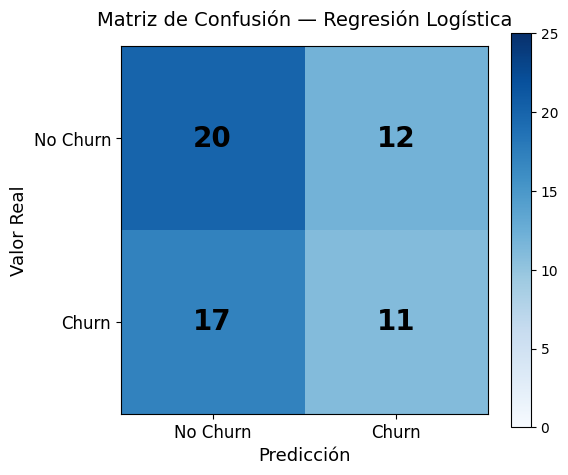

In [22]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>10. Matriz de Confusión</h3>"))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

# Colores más suaves: blanco a azul claro
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max() + 5)
plt.colorbar(im)

ax.set_xticks([0, 1]); ax.set_xticklabels(["No Churn", "Churn"], fontsize=12)
ax.set_yticks([0, 1]); ax.set_yticklabels(["No Churn", "Churn"], fontsize=12)
ax.set_xlabel("Predicción", fontsize=13)
ax.set_ylabel("Valor Real", fontsize=13)
ax.set_title("Matriz de Confusión — Regresión Logística", fontsize=14, pad=15)

# Texto siempre en negro para que se lea bien
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=20, fontweight="bold", color="black")

plt.tight_layout()
plt.show()

Se grafica la curva ROC que muestra la relación entre la tasa de verdaderos
positivos y falsos positivos para todos los umbrales posibles. Cuanto más
cerca del vértice superior izquierdo, mejor el modelo. El área bajo la curva
(AUC) resume ese desempeño en un solo número: 1 es perfecto, 0.5 es aleatorio.

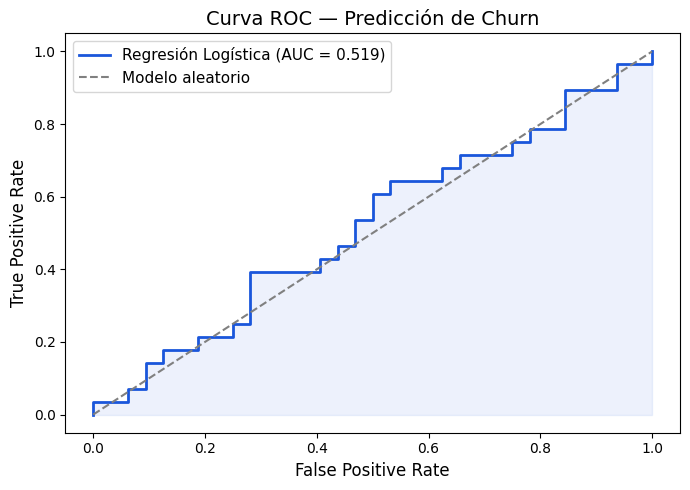

In [23]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>11. Curva ROC</h3>"))

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#1A56DB", lw=2,
         label=f"Regresión Logística (AUC = {round(auc, 3)})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modelo aleatorio")
plt.fill_between(fpr, tpr, alpha=0.08, color="#1A56DB")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Curva ROC — Predicción de Churn", fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

el modelo con 300 filas no tiene suficiente información para aprender el patrón de churn de forma confiable

Se muestra una tabla con las primeras 10 predicciones del modelo, comparando
el valor real de Churn, el valor predicho y la probabilidad estimada de abandono
para cada cliente. Esto permite ver el modelo en acción con casos concretos.

In [24]:
display(HTML("<h3 style='color:#1A56DB; font-family:Arial'>12. Primeras predicciones</h3>"))

results = pd.DataFrame({
    "Churn real":       y_test.map({0: "No", 1: "Sí"}).values,
    "Churn predicho":   pd.Series(y_pred).map({0: "No", 1: "Sí"}).values,
    "Probabilidad Churn": [f"{p:.1%}" for p in y_prob]
})

display(results.head(10))

,Churn real,Churn predicho,Probabilidad Churn
0,No,No,46.4%
1,No,No,41.6%
2,No,No,34.2%
3,No,Sí,83.3%
4,No,Sí,56.9%
5,No,No,32.9%
6,Sí,Sí,60.5%
7,No,No,28.9%
8,Sí,Sí,53.0%
9,No,No,37.9%


In [25]:
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Re-define df
df = pd.read_csv("/content/TP customer_churn_prediction_dataset.csv")

# Re-define X and y
target = "Churn"
X = df.drop(columns=[target, "customerID"])
y = df[target]
y = y.map({"No": 0, "Yes": 1})

# Re-define X_encoded (preprocessing)
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

X_encoded = pd.get_dummies(X, drop_first=True)

# Re-define X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Re-scale X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Re-train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Original code to calculate and display importance
importancia = pd.DataFrame({
    "Variable": X_encoded.columns,
    "Coeficiente": model.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False).head(10)
display(importancia)

,Variable,Coeficiente
3,TotalCharges,0.574308
1,tenure,-0.515086
2,MonthlyCharges,-0.456831
19,TechSupport_Yes,-0.291740
29,PaymentMethod_Mailed check,-0.248738
20,StreamingTV_No internet service,-0.223760
15,OnlineBackup_Yes,0.205905
23,StreamingMovies_Yes,-0.182846
14,OnlineBackup_No internet service,0.171563
18,TechSupport_No internet service,-0.169141


# Conclusiones y Acciones

El modelo de regresión logística fue entrenado con 240 clientes y evaluado sobre 60 clientes. El dataset presenta una distribución relativamente balanceada: 53.7% no abandonó el servicio y 46.3% sí lo hizo.

# Rendimiento del modelo

El modelo obtuvo un Accuracy de 51.7% y un AUC de 0.519, lo que indica un rendimiento cercano al azar. Esto significa que en su estado actual el modelo no logra distinguir de forma confiable entre clientes que van a abandonar y los que no. Las principales causas posibles son el tamaño reducido del dataset (300 filas) y la necesidad de ajustar mejor las variables predictoras.

## De los 60 clientes evaluados:
11 clientes con churn real fueron correctamente identificados como churn (verdaderos positivos)
20 clientes sin churn fueron correctamente identificados como no churn (verdaderos negativos)
17 clientes iban a hacer churn pero el modelo no los detectó (falsos negativos) — el error más costoso para la empresa
12 clientes no iban a hacer churn pero el modelo predijo que sí (falsos positivos) — genera campañas de retención innecesarias

# A corto plazo:
Enfocar campañas de retención en los 3 clientes de alto riesgo, ofreciendo descuentos personalizados o mejoras en el servicio.

Priorizar la retención de clientes con contrato mensual y baja antigüedad, ya que el EDA mostró que son los más propensos al abandono

Integrar el modelo al CRM para generar alertas automáticas cuando un cliente supere el umbral del 50% de probabilidad de churn

# A mediano plazo:
Reentrenar el modelo con más datos históricos para mejorar el AUC por encima de 0.7
Evaluar variables adicionales como historial de reclamos o frecuencia de uso del servicio que puedan mejorar el poder predictivo
Comparar el rendimiento con otros modelos.